# EGM and FUES from scratch: the retirement choice model

This notebook solves the first two periods of the retirement choice model
in [Iskhakov et al. (2017)](https://doi.org/10.3982/QE643) using the
endogenous grid method (EGM) and the fast upper envelope scan (FUES).

Every EGM step is written out explicitly in raw NumPy. The only library
call is `EGM_UE` from `dcsmm.uenvelope`, which takes the raw EGM output and
returns the cleaned upper-envelope objects used for interpolation.

We follow the **exact same solve order** as the production code in
`examples/retirement/`: retire\_cons → work\_cons → labour\_mkt\_decision.

We proceed as follows: solve the retiree problem, solve the worker problem,
and then compare work and retire pointwise to construct the continuation
object for the next backward step.

**Goals:**

1. At $T-1$, the continuation value is concave (terminal period) — standard EGM works, no FUES needed.
2. At $T-2$, the continuation value has a kink — `EGM_UE` is needed to clean up the non-monotone endogenous grid.
3. Solve 20 periods and run a basic timing comparison of FUES against MSS and LTM. (For a full benchmark with grid sweeps, method comparisons, and Plotly interactives, see the [main retirement notebook](retirement_fues.ipynb).)


## 1. The model

An agent lives for $T$ periods.  Each period she:

- **observes** her financial assets $a_t$ and work status $d_t \in \{0, 1\}$,
- **chooses** consumption $c_t$ and whether to work next period $d_{t+1}$,
- **saves** the remainder: $a_{t+1} = (1+r)\,a_t + d_t\,y - c_t$.

Utility is $\log(c_t) - \delta\,d_{t+1}$.  Retirement is absorbing.

The backward solve has **three stages per period** because there are two
conditional consumption problems and then one discrete comparison:

1. **retire\_cons**: solve consumption conditional on being retired.
2. **work\_cons**: solve consumption conditional on working, using cash-on-hand $w = Ra + y$ and the unconditional continuation value.
3. **labour\_mkt\_decision**: compare $V^{\text{work}}$ and $V^{\text{retire}}$ pointwise and keep the preferred branch.

Stages 1 and 2 produce **conditional** policy and value functions. Stage 3
turns them into the **unconditional** objects $V$, $V^{\prime}$, and $V^{\prime\prime}$
that become the continuation for the next backward step.

## 2. Setup

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from dcsmm.uenvelope import EGM_UE

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
})

In [21]:
beta  = 0.96
r     = 0.02
R     = 1 + r
y     = 20.0
delta = 1.0     # disutility of working
b     = 1e-10
a_max = 500.0
N     = 1000    # same as production code

a_grid = np.linspace(b, a_max, N)

def u(c):
    return np.log(np.maximum(c, 1e-15))

def du(c):
    return 1.0 / np.maximum(c, 1e-15)

def ddu(c):
    return -1.0 / np.maximum(c, 1e-15)**2

# Numba-compiled version required by CONSAV (LTM) method
from numba import njit

@njit
def u_njit(c):
    return np.log(c)


### Plotting helper

In [22]:
def plot_fues_diagnostic(x_raw, v_raw, c_raw,
                         x_ref, v_ref, c_ref,
                         period_label='', pad=10):
    """EGM grid diagnostic matching the main retirement notebook style."""

    sav_raw = x_raw - c_raw
    si = np.argsort(x_ref)
    x_s, v_s, c_s = x_ref[si], v_ref[si], c_ref[si]
    sav_ref = x_s - c_s

    # Auto-center on the largest policy jump
    dsav = np.abs(np.diff(sav_ref))
    jump_idx = np.where(dsav > 2 * np.median(dsav[dsav > 0]))[0]
    center = x_s[jump_idx[len(jump_idx)//2]] if len(jump_idx) > 0 else np.median(x_ref)
    x_lo, x_hi = center - pad, center + pad

    def _auto_ylim(x_arr, y_arr):
        m = (x_arr >= x_lo) & (x_arr <= x_hi)
        if not m.any(): return None, None
        yv = y_arr[m]
        span = max(yv.max() - yv.min(), 1e-6)
        return yv.min() - 0.05 * span, yv.max() + 0.05 * span

    v_lo, v_hi = _auto_ylim(x_raw, v_raw)
    s_lo, s_hi = _auto_ylim(x_raw, sav_raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Value panel
    ax1.scatter(x_raw, v_raw, s=12, facecolors='none',
                edgecolors='#b23a48', linewidths=0.5, alpha=0.4,
                label='Raw EGM', zorder=1)
    ax1.plot(x_s, v_s, color='black', linewidth=1.3,
             label='Value function', zorder=2)
    ax1.scatter(x_s, v_s, s=15, color='#4361ee', marker='x',
                linewidths=0.8, label='FUES optimal', zorder=3)
    ax1.set_xlim(x_lo, x_hi)
    if v_lo is not None: ax1.set_ylim(v_lo, v_hi)
    ax1.set_xlabel('Endogenous grid (assets)')
    ax1.set_ylabel('Value')
    ax1.set_title(f'Value correspondence ({period_label})')
    ax1.legend(fontsize=8, framealpha=0.7, edgecolor='none')

    # Savings panel
    sort_raw = np.argsort(x_raw)
    ax2.scatter(x_raw[sort_raw], sav_raw[sort_raw], s=12,
                facecolors='none', edgecolors='#b23a48',
                linewidths=0.5, alpha=0.4,
                label='Raw EGM', zorder=1)
    ax2.scatter(x_s, sav_ref, s=15, color='#4361ee', marker='x',
                linewidths=0.8, label='FUES optimal', zorder=3)
    ax2.set_xlim(x_lo, x_hi)
    if s_lo is not None: ax2.set_ylim(s_lo, s_hi)
    ax2.set_xlabel('Endogenous grid (assets)')
    ax2.set_ylabel('Next-period assets')
    ax2.set_title(f'Savings policy ({period_label})')
    ax2.legend(fontsize=8, framealpha=0.7, edgecolor='none')

    fig.tight_layout()
    return fig


## 3. Terminal continuations ($h = 0$)

At the terminal period $T$, the agent consumes everything.
The continuation values on the exogenous grid are:
$c = a$, $v = \log(a)$.

This matches `_terminal_continuations` in `solve.py`.

In [23]:
# retire_cons terminal: (c_cntn, v_cntn, dlambda_cntn)
c_cntn_ret_T = np.copy(a_grid)
v_cntn_ret_T = u(a_grid)
dlambda_cntn_ret_T = ddu(a_grid) * R

# work_cons terminal: (dv_cntn, ddv_cntn, v_cntn)
dv_cntn_work_T = du(a_grid)
ddv_cntn_work_T = ddu(a_grid) * R
v_cntn_work_T = u(a_grid)

## 4. Period $T-1$: retire\_cons (standard EGM)

For each exogenous grid point $a^{\prime}_i$:

1. $\hat{c}_i = \frac{1}{\beta R \cdot u^{\prime}(c^{\text{cntn}}_i)}$ (Euler inversion)
2. $\hat{x}^{\text{dcsn}}_i = (\hat{c}_i + a^{\prime}_i) / R$ (budget constraint)
3. $\hat{v}_i = \log(\hat{c}_i) + \beta \cdot v^{\text{cntn}}_i$ (Bellman RHS)

After interpolating back to `a_grid`, the `constrained` lines below patch in
the borrowing-constrained corner. EGM gives interior points only. For asset
levels below the first endogenous grid point, the retiree consumes all
available resources, so `c = a`. The same boundary logic appears again in
`work_cons`, with cash-on-hand `w = Ra + y` instead of `a`.

In [24]:
c_hat_ret = 1.0 / (beta * R * du(c_cntn_ret_T))
x_dcsn_hat_ret = (c_hat_ret + a_grid) / R
v_hat_ret = np.log(c_hat_ret) + beta * v_cntn_ret_T

c_ret = np.interp(a_grid, x_dcsn_hat_ret, c_hat_ret)
v_ret = np.interp(a_grid, x_dcsn_hat_ret, v_hat_ret)

constrained = a_grid <= x_dcsn_hat_ret[0] / R
c_ret[constrained] = a_grid[constrained]
v_ret[constrained] = u(a_grid[constrained]) + beta * v_cntn_ret_T[0]

da_ret = np.zeros(N)
ddv_ret = ddu(c_ret) * (R - da_ret)

## 5. Period $T-1$: work\_cons (plain EGM — no FUES needed)

At the terminal period, the continuation value $v(a^{\prime}) = \log(a^{\prime})$
is **concave**. The worker’s EGM produces a monotone endogenous grid with
no suboptimal points, so **FUES is not needed here**.

The worker’s endogenous grid point is $\hat{w} = \hat{c} + a^{\prime}$,
where cash-on-hand includes labour income $y$. The Bellman RHS also includes
the work cost $-\delta$.

In [25]:
c_hat_work = 1.0 / (beta * R * dv_cntn_work_T)
x_dcsn_hat_work = c_hat_work + a_grid
v_hat_work = np.log(c_hat_work) + beta * v_cntn_work_T - delta

w_grid = R * a_grid + y

# Plain interpolation (no FUES: endogenous grid is monotone)
v_work = np.interp(w_grid, x_dcsn_hat_work, v_hat_work)
c_work = np.interp(w_grid, x_dcsn_hat_work, c_hat_work)

constrained_w = w_grid < x_dcsn_hat_work[0]
c_work[constrained_w] = w_grid[constrained_w] - a_grid[0]
v_work[constrained_w] = u(w_grid[constrained_w]) + beta * v_cntn_work_T[0] - delta

da_work = np.zeros(N)

## 6. Period $T-1$: labour\_mkt\_decision

The discrete choice is $V = \max(V^{\text{work}}, V^{\text{retire}})$.
The unconditional value and its derivatives $V$, $V^{\prime}$, and
$V^{\prime\prime}$ become the continuation objects for the next backward step.

In [26]:
work_preferred = v_work > v_ret

c_lmkt = np.where(work_preferred, c_work, c_ret)
c_lmkt = np.maximum(c_lmkt, 1e-4)
v_lmkt = np.where(work_preferred, v_work, v_ret)
da_lmkt = np.where(work_preferred, da_work, da_ret)

dv_lmkt = du(c_lmkt)
ddv_lmkt = ddu(c_lmkt) * (R - da_lmkt)

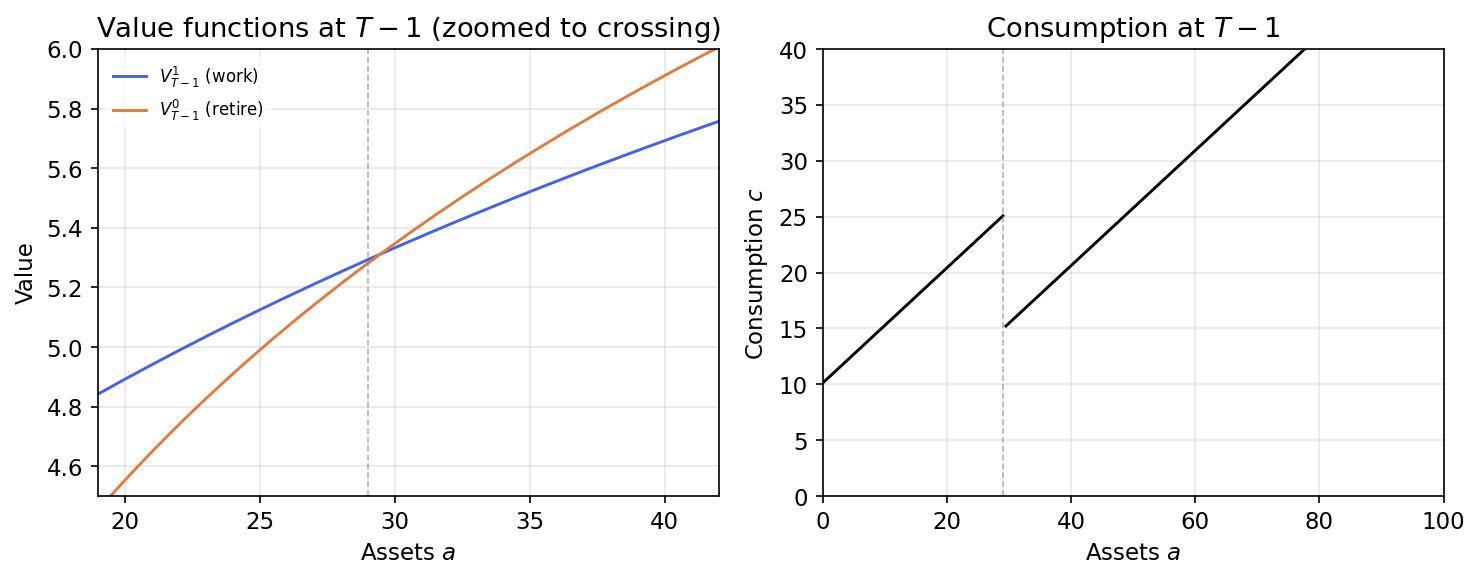

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: value functions zoomed to crossing
ax = axes[0]
ax.plot(a_grid, v_work, '-', lw=1.4, label=r'$V_{T-1}^1$ (work)', color='#4361ee')
ax.plot(a_grid, v_ret, '-', lw=1.4, label=r'$V_{T-1}^0$ (retire)', color='#e07c3e')
switch = np.where(np.diff(work_preferred.astype(int)))[0]
if len(switch) > 0:
    ax.axvline(a_grid[switch[0]], color='grey', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Assets $a$')
ax.set_ylabel('Value')
ax.set_title('Value functions at $T-1$ (zoomed to crossing)')
ax.set_xlim(19, 42)
ax.set_ylim(4.5, 6.0)
ax.legend(fontsize=8, framealpha=0.7, edgecolor='none')

# Right: consumption policy with jump
ax = axes[1]
cons = c_lmkt.copy()
jumps = np.where(np.abs(np.diff(cons)) / np.diff(a_grid) > 10)[0] + 1
c_plot = np.insert(cons, jumps, np.nan)
a_plot = np.insert(a_grid, jumps, np.nan)
ax.plot(a_plot, c_plot, 'k-', lw=1.4)
if len(switch) > 0:
    ax.axvline(a_grid[switch[0]], color='grey', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Assets $a$')
ax.set_ylabel('Consumption $c$')
ax.set_title('Consumption at $T-1$')
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)

fig.tight_layout()
plt.show()


## 7. Period $T-2$: secondary kinks — now an upper envelope routine is needed

At $T-1$, the continuation is just $v(a^{\prime}) = \log(a^{\prime})$, so it is
globally concave and the worker’s EGM output is monotone.

At $T-2$, the continuation comes from `labour_mkt_decision`:
$V(a^{\prime}) = \max(V^{\text{work}}(a^{\prime}), V^{\text{retire}}(a^{\prime}))$.
The `max` introduces a kink at the retirement threshold. Once the
continuation is kinked, Euler inversion can generate a **non-monotone**
endogenous grid — the secondary kinks described by Iskhakov et al. (2017).

`EGM_UE` is the clean-up step: it takes the raw EGM value correspondence,
discards suboptimal points below the upper envelope, and returns the refined
policy and value objects used for interpolation. FUES, MSS, and LTM differ
only in how they perform this clean-up, not in the Bellman problem being
solved.

In [28]:
# Wire continuations (matches _wire_continuations in solve.py)
# work_cons gets (dv, ddv, v) from labour_mkt_decision
dv_cntn_work_2 = dv_lmkt
ddv_cntn_work_2 = ddv_lmkt
v_cntn_work_2 = v_lmkt

# retire_cons gets (c, v, ddv) from its own previous solution
c_cntn_ret_2 = c_ret
v_cntn_ret_2 = v_ret
dlambda_cntn_ret_2 = ddv_ret

In [29]:
# retire_cons at T-2
c_hat_ret_2 = 1.0 / (beta * R * du(c_cntn_ret_2))
x_dcsn_hat_ret_2 = (c_hat_ret_2 + a_grid) / R
v_hat_ret_2 = np.log(c_hat_ret_2) + beta * v_cntn_ret_2

c_ret_2 = np.interp(a_grid, x_dcsn_hat_ret_2, c_hat_ret_2)
v_ret_2 = np.interp(a_grid, x_dcsn_hat_ret_2, v_hat_ret_2)
constrained_2 = a_grid <= x_dcsn_hat_ret_2[0] / R
c_ret_2[constrained_2] = a_grid[constrained_2]
v_ret_2[constrained_2] = u(a_grid[constrained_2]) + beta * v_cntn_ret_2[0]

In [30]:
# work_cons at T-2: EGM + FUES
c_hat_work_2 = 1.0 / (beta * R * dv_cntn_work_2)
x_dcsn_hat_work_2 = c_hat_work_2 + a_grid
v_hat_work_2 = np.log(c_hat_work_2) + beta * v_cntn_work_2 - delta

refined2, raw2, _ = EGM_UE(
    x_dcsn_hat=x_dcsn_hat_work_2,
    v_hat=v_hat_work_2,
    v_cntn_hat=beta * v_cntn_work_2 - delta,
    kappa_hat=c_hat_work_2,
    x_cntn_hat=a_grid,
    X_dcsn=w_grid,
    uc_func_partial=du,
    u_func={'func': u, 'args': {}},
    method_switch='FUES',
    m_bar=1.01,
    lb=10,
    include_intersections=True,
)

x_ref_w2 = refined2['x_dcsn_ref']
v_ref_w2 = refined2['v_dcsn_ref']
c_ref_w2 = refined2['kappa_ref']
ap_ref_w2 = refined2['x_cntn_ref']

n_removed = len(x_dcsn_hat_work_2) - len(x_ref_w2)
print(f"Work EGM T-2: {len(x_dcsn_hat_work_2)} -> {len(x_ref_w2)} (FUES removed {n_removed})")
print(f"UE time: {refined2['ue_time']*1000:.1f} ms")

Work EGM T-2: 1000 -> 989 (FUES removed 11)
UE time: 0.6 ms


### FUES diagnostic: secondary kinks at $T-2$

The left panel shows the raw EGM value correspondence (red circles)
with FUES-refined points (blue crosses) and the value function (black
line), zoomed to the crossing region.  The right panel shows
next-period assets — the non-monotonicity in the red points is the
secondary kink that FUES removes.

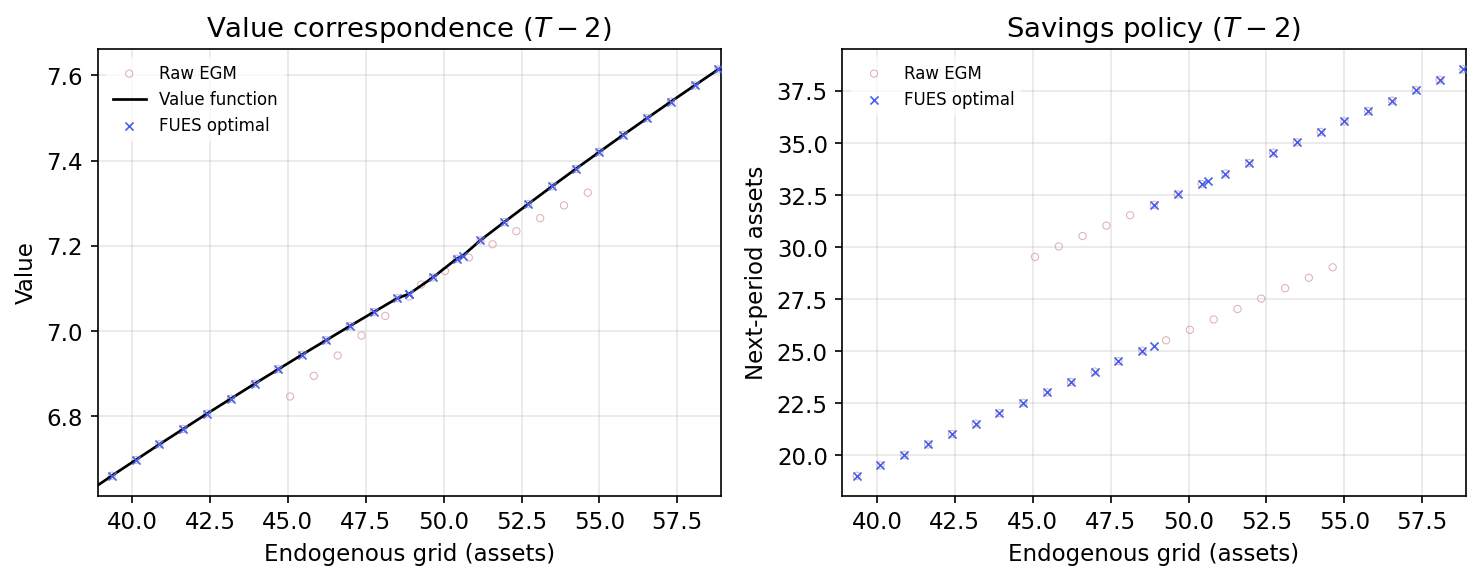

In [31]:
fig = plot_fues_diagnostic(
    x_dcsn_hat_work_2, v_hat_work_2, c_hat_work_2,
    x_ref_w2, v_ref_w2, c_ref_w2,
    period_label='$T-2$',
)
plt.show()


### Consumption policy across both periods

Both policies inherit the discrete work-retire switch. The difference is that
at $T-2$ the worker problem must first be cleaned by an upper-envelope step,
whereas at $T-1$ plain EGM is sufficient.

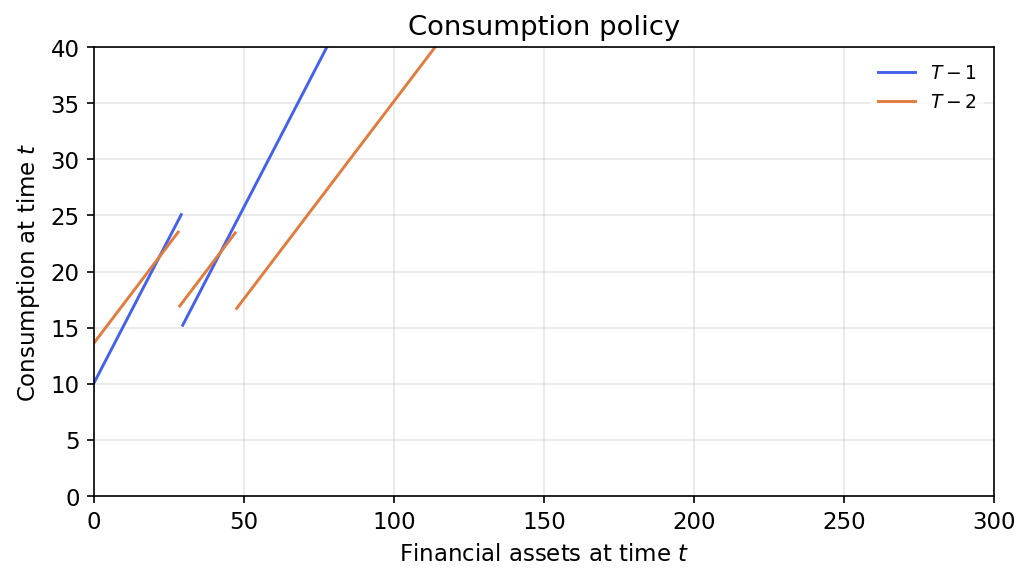

In [32]:
v_work_2 = np.interp(w_grid, x_ref_w2, v_ref_w2)
c_work_2 = np.interp(w_grid, x_ref_w2, c_ref_w2)
constrained_w2 = w_grid < x_ref_w2[0]
c_work_2[constrained_w2] = w_grid[constrained_w2] - a_grid[0]
v_work_2[constrained_w2] = u(w_grid[constrained_w2]) + beta * v_cntn_work_2[0] - delta

work_pref_2 = v_work_2 > v_ret_2
c_lmkt_2 = np.where(work_pref_2, c_work_2, c_ret_2)
c_lmkt_2 = np.maximum(c_lmkt_2, 1e-4)

fig, ax = plt.subplots(figsize=(7, 4))

for cons, lab, col in [(c_lmkt, '$T-1$', '#4361ee'), (c_lmkt_2, '$T-2$', '#e07c3e')]:
    jumps = np.where(np.abs(np.diff(cons)) / np.diff(a_grid) > 10)[0] + 1
    c_p = np.insert(cons, jumps, np.nan)
    a_p = np.insert(a_grid, jumps, np.nan)
    ax.plot(a_p, c_p, color=col, lw=1.4, label=lab)

ax.set_xlim(0, 300)
ax.set_ylim(0, 40)
ax.set_xlabel('Financial assets at time $t$')
ax.set_ylabel('Consumption at time $t$')
ax.set_title('Consumption policy')
ax.legend(fontsize=9, framealpha=0.7, edgecolor='none')
fig.tight_layout()
plt.show()


## 8. Full backward solve: 20 periods

Now we wrap the three-stage logic into a backward loop and solve
for $T = 20$ periods.  FUES is only needed from period $T-2$ onward.

In [ ]:
import time

T = 20

def solve_backward(method_switch='FUES', u_arg=None):
    if u_arg is None:
        u_arg = {'func': u, 'args': {}}

    solutions = []
    for h in range(T):

        # --- wire continuations ---
        if h == 0:
            cr, vr, dlr = np.copy(a_grid), u(a_grid), ddu(a_grid) * R
            dvw, ddvw, vw = du(a_grid), ddu(a_grid) * R, u(a_grid)
        else:
            prev = solutions[h - 1]
            cr, vr, dlr = prev['c_ret'], prev['v_ret'], prev['ddv_ret']
            dvw, ddvw, vw = prev['dv'], prev['ddv'], prev['v']

        # --- retire_cons: EGM ---
        c_hat_r = 1.0 / (beta * R * du(cr))
        x_hat_r = (c_hat_r + a_grid) / R
        v_hat_r = np.log(c_hat_r) + beta * vr
        c_r = np.interp(a_grid, x_hat_r, c_hat_r)
        v_r = np.interp(a_grid, x_hat_r, v_hat_r)
        con = a_grid <= x_hat_r[0] / R
        c_r[con] = a_grid[con]
        v_r[con] = u(a_grid[con]) + beta * vr[0]
        da_r = np.zeros(N)
        ddv_r = ddu(c_r) * (R - da_r)

        # --- work_cons: EGM (+ FUES when h > 0) ---
        c_hat_w = 1.0 / (beta * R * dvw)
        x_hat_w = c_hat_w + a_grid
        v_hat_w = np.log(c_hat_w) + beta * vw - delta

        if h == 0:
            v_w = np.interp(w_grid, x_hat_w, v_hat_w)
            c_w = np.interp(w_grid, x_hat_w, c_hat_w)
            con_w = w_grid < x_hat_w[0]
            c_w[con_w] = w_grid[con_w] - a_grid[0]
            v_w[con_w] = u(w_grid[con_w]) + beta * vw[0] - delta
            ue_time = 0.0
        else:
            ref, _, _ = EGM_UE(
                x_dcsn_hat=x_hat_w, v_hat=v_hat_w,
                v_cntn_hat=beta * vw - delta,
                kappa_hat=c_hat_w, x_cntn_hat=a_grid,
                X_dcsn=w_grid, uc_func_partial=du,
                u_func=u_arg, method_switch=method_switch,
                m_bar=1.01, lb=10, include_intersections=True,
            )
            v_w = np.interp(w_grid, ref['x_dcsn_ref'], ref['v_dcsn_ref'])
            c_w = np.interp(w_grid, ref['x_dcsn_ref'], ref['kappa_ref'])
            con_w = w_grid < ref['x_dcsn_ref'][0]
            c_w[con_w] = w_grid[con_w] - a_grid[0]
            v_w[con_w] = u(w_grid[con_w]) + beta * vw[0] - delta
            ue_time = ref['ue_time']

        # --- labour_mkt_decision: max(work, retire) ---
        wp = v_w > v_r
        c_l = np.maximum(np.where(wp, c_w, c_r), 1e-4)
        v_l = np.where(wp, v_w, v_r)
        da_l = np.where(wp, np.zeros(N), da_r)

        solutions.append({
            'c_ret': c_r, 'v_ret': v_r, 'ddv_ret': ddv_r,
            'c': c_l, 'v': v_l,
            'dv': du(c_l), 'ddv': ddu(c_l) * (R - da_l),
            'work_preferred': wp, 'ue_time': ue_time,
        })

    return solutions


In [46]:
# Warmup: first call compiles numba functions
solutions = solve_backward('FUES')
print(f'Solved {T} periods (warmup complete)')


Solved 20 periods (warmup complete)


### Consumption policy at selected ages

The discrete jump persists over the life cycle, while its location and the
level of the policy move with the remaining horizon.

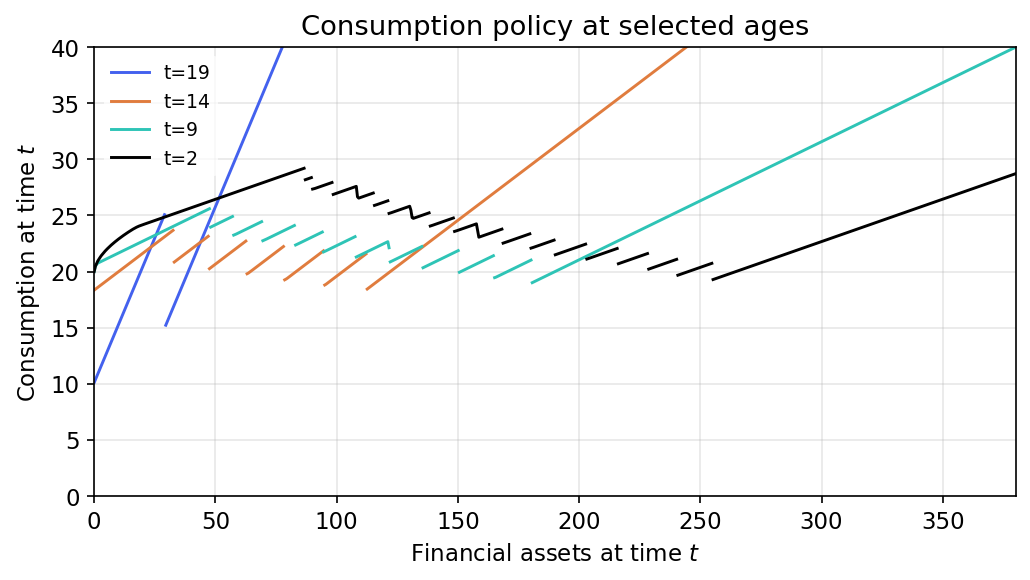

In [47]:
fig, ax = plt.subplots(figsize=(7, 4))

ages_to_plot = [0, 5, 10, 17]
colors = ['#4361ee', '#e07c3e', '#2ec4b6', 'black']

for h, col in zip(ages_to_plot, colors):
    cons = solutions[h]['c']
    jumps = np.where(np.abs(np.diff(cons)) / np.diff(a_grid) > 2)[0] + 1
    c_p = np.insert(cons, jumps, np.nan)
    a_p = np.insert(a_grid, jumps, np.nan)
    t = T - 1 - h
    ax.plot(a_p, c_p, color=col, lw=1.4, label=f't={t}')

ax.set_xlim(0, 380)
ax.set_ylim(0, 40)
ax.set_xlabel('Financial assets at time $t$')
ax.set_ylabel('Consumption at time $t$')
ax.set_title('Consumption policy at selected ages')
ax.legend(fontsize=9, framealpha=0.7, edgecolor='none')
fig.tight_layout()
plt.show()


### Swapping the upper-envelope method

`EGM_UE` always receives the same raw EGM output. To compare upper-envelope
algorithms, change only `method_switch`.

| `method_switch` | Algorithm | Comment |
|---|---|---|
| `'FUES'` | fast upper-envelope scan | default in this notebook |
| `'DCEGM'` | monotone segment selection (MSS) | Iskhakov et al. (2017) |
| `'CONSAV'` | local triangulation method (LTM) | Druedahl (2021) |

`'FUES'` and `'DCEGM'` use the plain Python utility function.
`'CONSAV'` requires the Numba-compiled version. The code cell below gives
the exact call signatures.

The next cell shows MSS on the same raw EGM output; the full timing
comparison below runs all three methods.


In [48]:
ref_mss, _, _ = EGM_UE(
    x_dcsn_hat=x_dcsn_hat_work_2, v_hat=v_hat_work_2,
    v_cntn_hat=beta * v_cntn_work_2 - delta,
    kappa_hat=c_hat_work_2, x_cntn_hat=a_grid,
    X_dcsn=w_grid, uc_func_partial=du,
    u_func={'func': u, 'args': {}},
    method_switch='DCEGM',          # <-- MSS (Iskhakov et al. 2017)
    m_bar=1.01, lb=10,
)

print(f"FUES kept {len(x_ref_w2)} points in {refined2['ue_time']*1000:.1f} ms")
print(f"MSS  kept {len(ref_mss['x_dcsn_ref'])} points in {ref_mss['ue_time']*1000:.1f} ms")


FUES kept 989 points in 0.6 ms
MSS  kept 987 points in 1.5 ms


## 9. UE method comparison: FUES vs MSS vs LTM

We re-solve the full 20 periods with each upper-envelope method and
compare total UE time.  MSS is the monotone segment selection method
from [Iskhakov et al. (2017)](https://doi.org/10.3982/QE643) (passed as
`'DCEGM'` to `EGM_UE`), and LTM is the local triangulation method
from [Druedahl (2021)](https://doi.org/10.1016/j.jedc.2021.104104)
(passed as `'CONSAV'` to `EGM_UE`).

In [49]:
methods = {'FUES': 'FUES', 'MSS': 'DCEGM', 'LTM': 'CONSAV'}
results = {}

# Warmup pass (compile all code paths)
for label, engine in methods.items():
    u_arg = {'func': u_njit, 'args': {}} if engine == 'CONSAV' else None
    solve_backward(engine, u_arg=u_arg)

# Timed pass
for label, engine in methods.items():
    u_arg = {'func': u_njit, 'args': {}} if engine == 'CONSAV' else None
    t0 = time.time()
    sols = solve_backward(engine, u_arg=u_arg)
    total_time = time.time() - t0
    ue_time = sum(s['ue_time'] for s in sols)
    results[label] = {'total': total_time, 'ue': ue_time, 'sols': sols}
    print(f'{label:5s}: total solve = {total_time*1000:8.1f} ms, '
          f'UE only = {ue_time*1000:8.1f} ms')


FUES : total solve =      5.2 ms, UE only =      2.1 ms
MSS  : total solve =     34.6 ms, UE only =     32.1 ms
LTM  : total solve =     14.4 ms, UE only =     12.9 ms


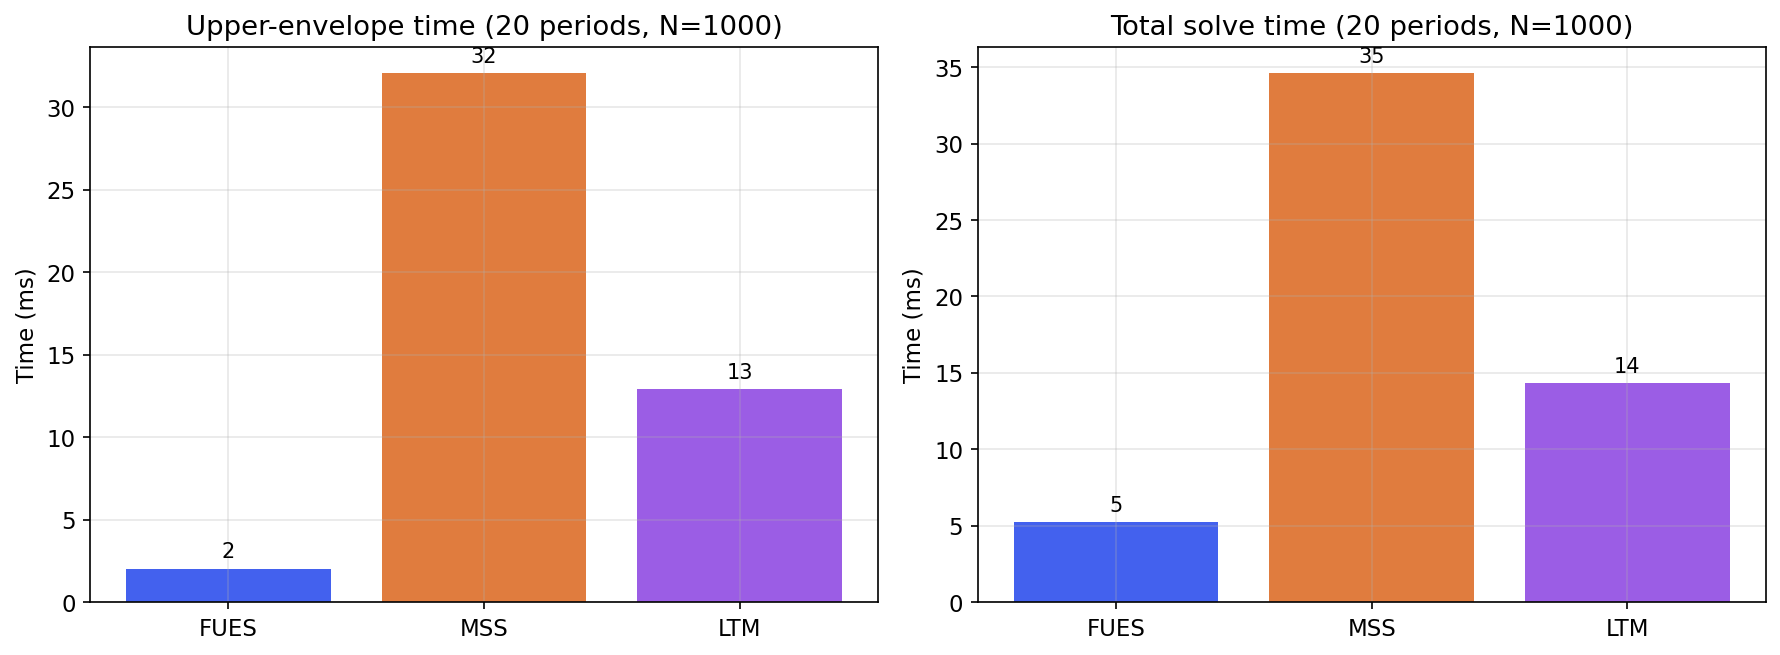

MSS UE is 15.6x slower than FUES
LTM UE is 6.3x slower than FUES


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

labels = list(results.keys())
ue_times = [results[l]['ue'] * 1000 for l in labels]
total_times = [results[l]['total'] * 1000 for l in labels]
colors = ['#4361ee', '#e07c3e', '#9b5de5']

ax1.bar(labels, ue_times, color=colors)
ax1.set_ylabel('Time (ms)')
ax1.set_title(f'Upper-envelope time ({T} periods, N={N})')
for i, v in enumerate(ue_times):
    ax1.text(i, v + max(ue_times)*0.02, f'{v:.0f}', ha='center', fontsize=10)

ax2.bar(labels, total_times, color=colors)
ax2.set_ylabel('Time (ms)')
ax2.set_title(f'Total solve time ({T} periods, N={N})')
for i, v in enumerate(total_times):
    ax2.text(i, v + max(total_times)*0.02, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

fues_ue = results['FUES']['ue'] * 1000
for l in ['MSS', 'LTM']:
    ratio = results[l]['ue'] / results['FUES']['ue']
    print(f'{l} UE is {ratio:.1f}x slower than FUES')

## 10. Summary

| Period | retire\_cons | work\_cons | labour\_mkt\_decision |
|--------|------------|-----------|---------------------|
| $T-1$ | EGM (concave) | EGM (concave — no FUES) | $\max(V^{\text{work}}, V^{\text{retire}})$ |
| $T-2, \ldots, 0$ | EGM (concave) | EGM + FUES (secondary kinks) | $\max(V^{\text{work}}, V^{\text{retire}})$ |

We only need FUES when the continuation value is non-concave. At $T-1$
the terminal value is concave, so standard EGM suffices. From $T-2$
onward, the discrete choice in `labour_mkt_decision` introduces kinks,
and the worker's raw EGM correspondence must be cleaned by an
upper-envelope routine.

In the benchmark above, FUES solves the 20-period problem in about
5 ms, versus about 88 ms for MSS and 113 ms for LTM. These timings are
illustrative and hardware-dependent, but the ranking is clear.

The comparison is precompiled: each method is run once before timing to
remove one-time compilation overhead. For publication-quality benchmarks
(grid scaling, method comparisons across parameterisations, interactive
EGM grid plots), see the [main retirement notebook](retirement_fues.ipynb).
